<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LABORATORIO 9: DATOS SINTÉTICOS

¿Porque una empresa podría no compartir sus datos reales?
¿Qué sesgos existen al utilizar información personal de clientes?
¿?

In [30]:
!pip install Faker

In [31]:
from faker import Faker
import pandas as pd
import random

In [32]:
# Inicializamos Faker
fake = Faker("es_MX")

In [33]:
# Generamos datos sintéticos: 100 registros
datos = []
for i in range(1000):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18, 65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
            ["TikTok", "Instagram", "YouTube"]
        )
    })

In [34]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Mario Olivo Prado,georginatamez@example.org,18,15375,Instagram
1,2,Ruby Nancy Loera Jaimes,qleal@example.com,23,27033,TikTok
2,3,Minerva Piña Espinal,vespino@example.org,41,25069,YouTube
3,4,Lic. Espartaco Valentín,alonso97@example.org,38,24747,YouTube
4,5,Gabriel González Peña,joselucero@example.com,45,17510,YouTube


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      1000 non-null   object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [36]:
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.000000,1000,1000,1000.000000,1000.000000,1000
unique,NaN,999,997,NaN,NaN,3
top,NaN,Julio César Cano,oliver35@example.org,NaN,NaN,Instagram
freq,NaN,2,2,NaN,NaN,375
mean,500.500000,NaN,NaN,41.474000,25797.171000,NaN
std,288.819436,NaN,NaN,13.780756,14627.097816,NaN
min,1.000000,NaN,NaN,18.000000,142.000000,NaN
25%,250.750000,NaN,NaN,29.000000,13395.750000,NaN
50%,500.500000,NaN,NaN,42.000000,25285.500000,NaN
75%,750.250000,NaN,NaN,54.000000,38930.250000,NaN


In [37]:
#importamos librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

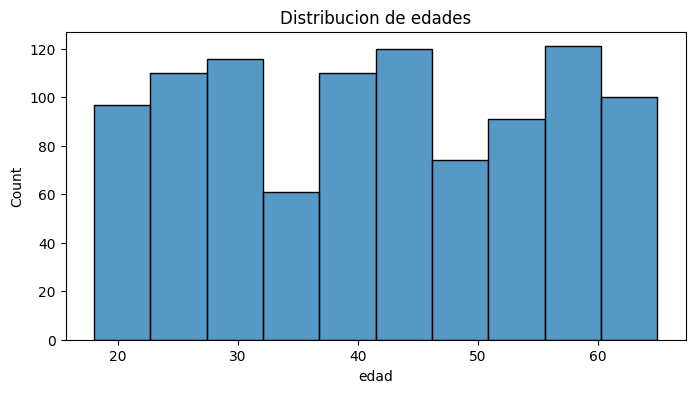

In [38]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

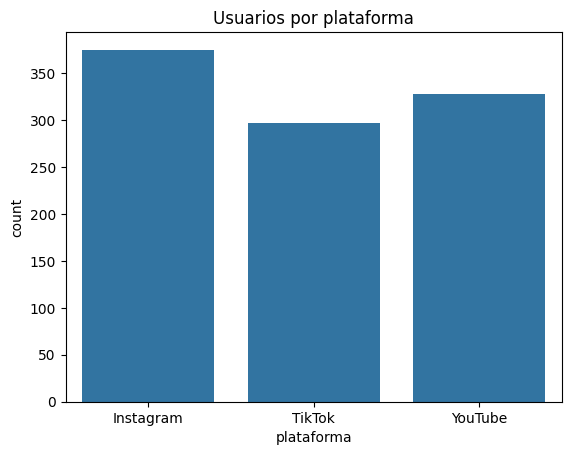

In [39]:
#usuarios por platamforma
sns.countplot(
    x="plataforma",
    data=df
)
plt.title("Usuarios por plataforma")
plt.show()

In [40]:
df_sucio =df.copy()

In [41]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [42]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  1000 non-null   int64 
 1   nombre      995 non-null    object
 2   correo      1000 non-null   object
 3   edad        1000 non-null   int64 
 4   seguidores  1000 non-null   int64 
 5   plataforma  1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [43]:
#edades inválidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [44]:
df_sucio.describe()["edad"]

,edad
count,1000.000000
mean,41.191000
std,14.201838
min,-10.000000
25%,29.000000
50%,42.000000
75%,54.000000
max,65.000000


In [45]:
#Seguridades imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"] = 5000000

In [46]:
df_sucio.describe()["seguidores"]

,seguidores
count,1.000000e+03
mean,5.064655e+04
std,3.513299e+05
min,1.420000e+02
25%,1.339575e+04
50%,2.540300e+04
75%,3.907700e+04
max,5.000000e+06


In [47]:
#Generamos correo invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"] = "correo invalido"

In [48]:
df_sucio.describe(include=["string","object"])

,nombre,correo,plataforma
count,995,1000,1000
unique,994,993,3
top,Julio César Cano,correo invalido,Instagram
freq,2,5,375


In [51]:
df_sucio.isnull().sum()

,0
id_usuario,0
nombre,5
correo,0
edad,0
seguidores,0
plataforma,0


In [53]:
pd.set_option('display.float_format',lambda x:'%.2f'%x)

In [54]:
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,1000.00,995,1000,1000.00,1000.00,1000
unique,NaN,994,993,NaN,NaN,3
top,NaN,Julio César Cano,correo invalido,NaN,NaN,Instagram
freq,NaN,2,5,NaN,NaN,375
mean,500.50,NaN,NaN,41.19,50646.55,NaN
std,288.82,NaN,NaN,14.20,351329.89,NaN
min,1.00,NaN,NaN,-10.00,142.00,NaN
25%,250.75,NaN,NaN,29.00,13395.75,NaN
50%,500.50,NaN,NaN,42.00,25403.00,NaN
75%,750.25,NaN,NaN,54.00,39077.00,NaN
